In [1]:
import numpy as np
import matplotlib.pyplot as pl
from scipy import integrate
from scipy import optimize
pl.rcParams['figure.dpi'] = 200

In [2]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

## Frequency error vs time

In [3]:
def beta_calc(f0, M):
    """M in units of solar masses"""
    Mc = M*2e30
    return const*f0**(8/3)*Mc**(5/3)

def t_max_calc(f0, beta, f_max):
    temp0 = 0.375/beta
    temp1 = 1-(f0/f_max)**(8/3)
    return temp0*temp1

def freq_err(t, f0, M, delta_beta):
    """Error in the frequency from the dephasing
    M in units of solar masses
    """
    beta = beta_calc(f0, M)
    temp0 = (3*f0*delta_beta)/(5*beta*(1-8/3*beta*t)**(3/8))
    temp1 = 1+(-1+beta*t)/(1-8/3*beta*t)
    return temp0*temp1

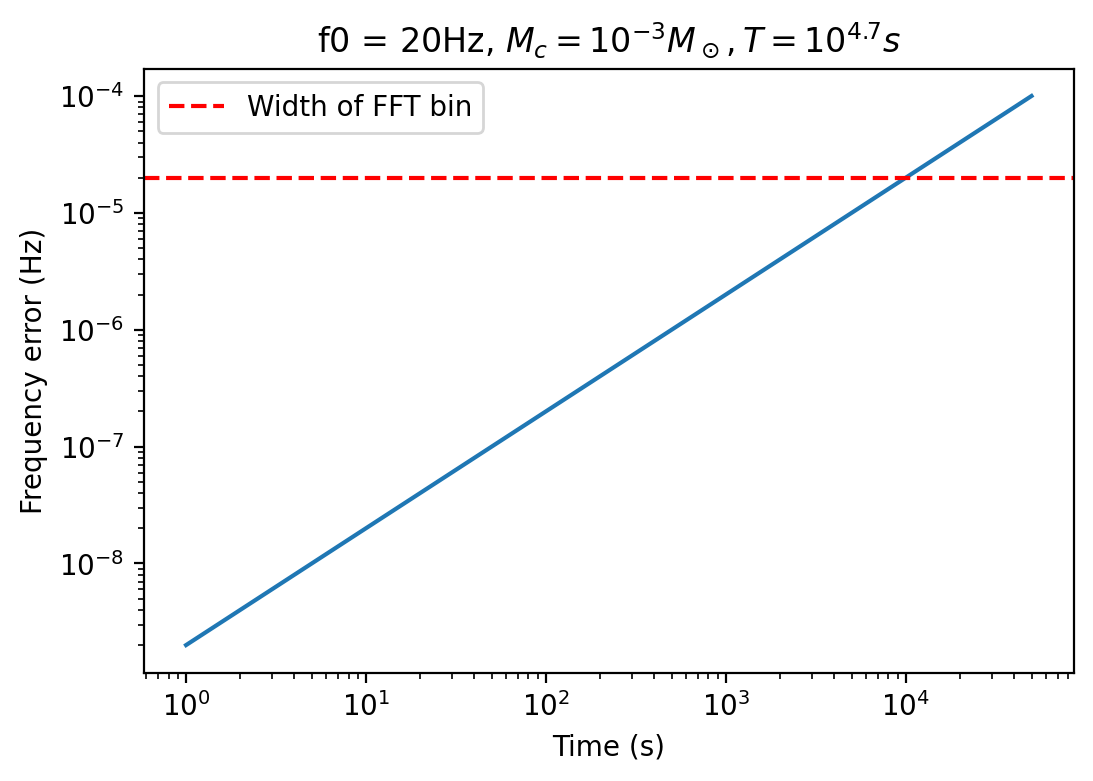

In [4]:
f0 = 20
M = 1e-3
beta = beta_calc(f0, M)
delta_beta = 1e-10

obs_duration = 5e4
T = min(obs_duration, t_max_calc(f0, beta, 200))

t_space = np.logspace(0, np.log10(T), 1000)
err_arr = abs(freq_err(t_space, f0, M, delta_beta))
pl.loglog(t_space, err_arr)
pl.axhline(1/T, c='r', ls='--', label="Width of FFT bin")
pl.legend()
pl.xlabel("Time (s)")
pl.ylabel("Frequency error (Hz)")
pl.title(r"f0 = %.0fHz, $M_c = 10^{%.0f} M_\odot, T = 10^{%.1f}s$" % 
         (f0, np.log10(M), np.log10(T)));

In [5]:
idx = np.argmin(abs(err_arr - 1/T))
crossover_t = t_space[idx]
crossover_t

9956.865172378946

In [6]:
phi = -6*pi/5*f0*(1-8./3.*beta*t_space)**(5/8)/beta

## Integrating to find lost power

In [9]:
phi - phi[0]

array([0.00000000e+00, 1.36841106e+00, 2.75172424e+00, 4.15010071e+00,
       5.56370449e+00, 6.99270153e+00, 8.43725967e+00, 9.89754868e+00,
       1.13737392e+01, 1.28660049e+01, 1.43745203e+01, 1.58994617e+01,
       1.74410105e+01, 1.89993458e+01, 2.05746508e+01, 2.21671085e+01,
       2.37769079e+01, 2.54042368e+01, 2.70492878e+01, 2.87122517e+01,
       3.03933239e+01, 3.20927038e+01, 3.38105869e+01, 3.55471783e+01,
       3.73026800e+01, 3.90772982e+01, 4.08712406e+01, 4.26847181e+01,
       4.45179434e+01, 4.63711329e+01, 4.82445002e+01, 5.01382694e+01,
       5.20526600e+01, 5.39878969e+01, 5.59442091e+01, 5.79218225e+01,
       5.99209728e+01, 6.19418917e+01, 6.39848175e+01, 6.60499897e+01,
       6.81376514e+01, 7.02480450e+01, 7.23814211e+01, 7.45380278e+01,
       7.67181196e+01, 7.89219513e+01, 8.11497803e+01, 8.34018707e+01,
       8.56784840e+01, 8.79798889e+01, 9.03063555e+01, 9.26581554e+01,
       9.50355654e+01, 9.74388638e+01, 9.98683329e+01, 1.02324259e+02,
      

In [48]:
def integrated_func_without_asd(t, f0, M):
    temp0 = np.power((1-8/3*beta_calc(f0, M)*t),-0.5)
    return temp0

def analytical_loss(offset, f0, M):
    temp_arr = []
    beta = beta_calc(f0, M)
    T = min(obs_duration, t_max_calc(f0, beta, 200))
    t_space = np.logspace(0, np.log10(T), 10000)
    for i in np.atleast_1d(offset):
        err_arr = abs(freq_err(t_space, f0, M, i))
        idx = np.argmin(abs(err_arr - 2/(T)))
        crossover_t = t_space[idx]

        temp0 = integrate.quad(integrated_func_without_asd, crossover_t, T, args = (f0, M))[0] 
        temp1 = integrate.quad(integrated_func_without_asd, 0, T, args = (f0, M))[0] 
        temp_arr.append(temp0/temp1)
    return np.array(temp_arr)

In [49]:
M

0.001

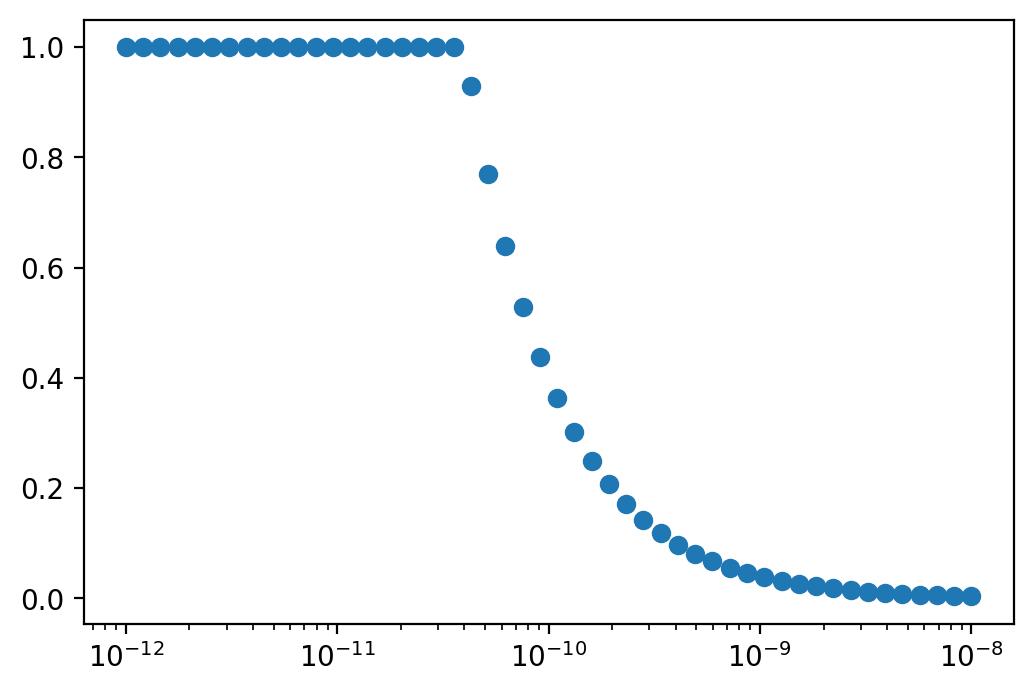

In [50]:
offset_arr = np.logspace(-12, -8, 50)
analytical_arr = analytical_loss(offset_arr, f0, M)
pl.semilogx(offset_arr, 1-analytical_arr, 'o')

## Comparison to cluster

In [51]:
cluster = np.loadtxt('results/f=20_M=1e-3_curve.txt')

Text(0, 0.5, 'Power recovered')

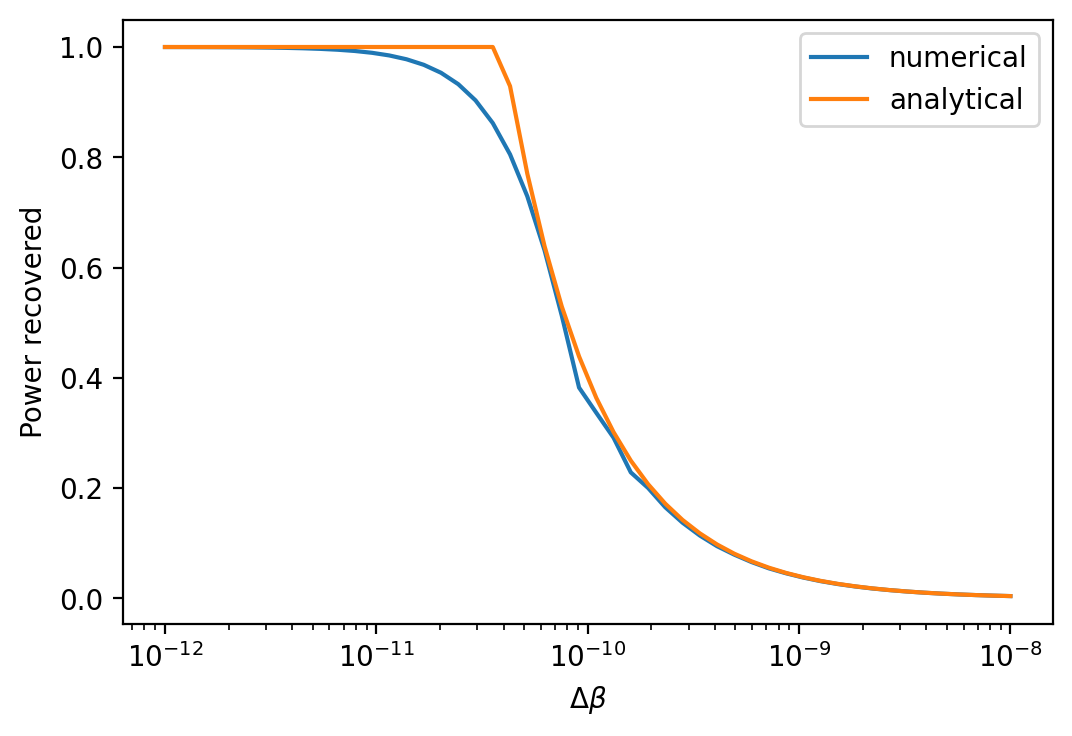

In [59]:
pl.semilogx(offset_arr, cluster, label='numerical')
pl.semilogx(offset_arr, 1-analytical_arr, label='analytical')
pl.legend()
pl.xlabel(r'$\Delta \beta$')
pl.ylabel("Power recovered")
# pl.title(r'$f_0 = 20, \, M_c = 10^{%.0f}M_\odot$' % np.log10(M))

## Calculating number of templates

In [104]:
f0 = 20
mass_space = np.logspace(-1, -2.5, 30)
beta_space = beta_calc(f0, mass_space)
offset_arr = np.logspace(-13, -9.5, 50)

In [105]:
scaling_30 = np.array([])
scaling_60 = np.array([])
scaling_90 = np.array([])

for m in mass_space:
    analytical_arr = analytical_loss(offset_arr, f0, m)
    scaling_30 = np.append(scaling_30, offset_arr[np.argmin(abs(1-analytical_arr-0.3))])
    scaling_60 = np.append(scaling_60, offset_arr[np.argmin(abs(1-analytical_arr-0.6))])
    scaling_90 = np.append(scaling_90, offset_arr[np.argmin(abs(1-analytical_arr-0.9))])

/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:15: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  from ipykernel import kernelapp as app


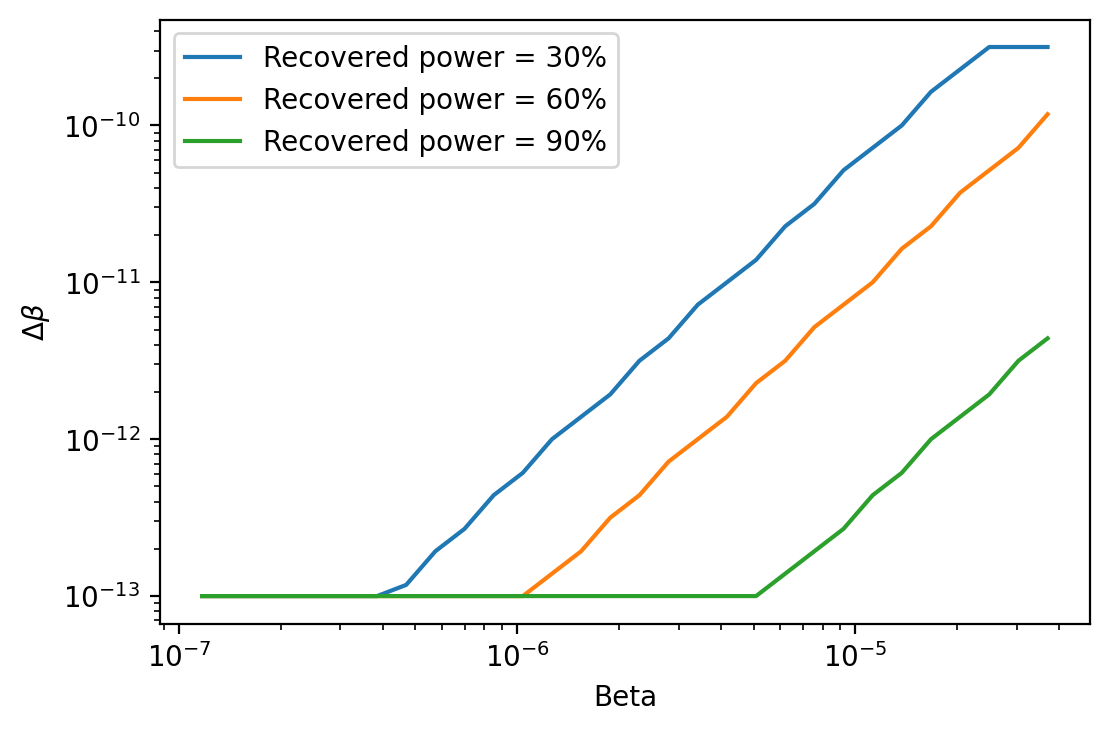

In [106]:
pl.loglog(beta_space, scaling_30, label='Recovered power = 30%')
pl.loglog(beta_space, scaling_60, label='Recovered power = 60%')
pl.loglog(beta_space, scaling_90, label='Recovered power = 90%')
# pl.axvline(beta_space[8], c='r', ls='--')
pl.xlabel("Beta")
pl.ylabel(r'$\Delta \beta$')
pl.legend()

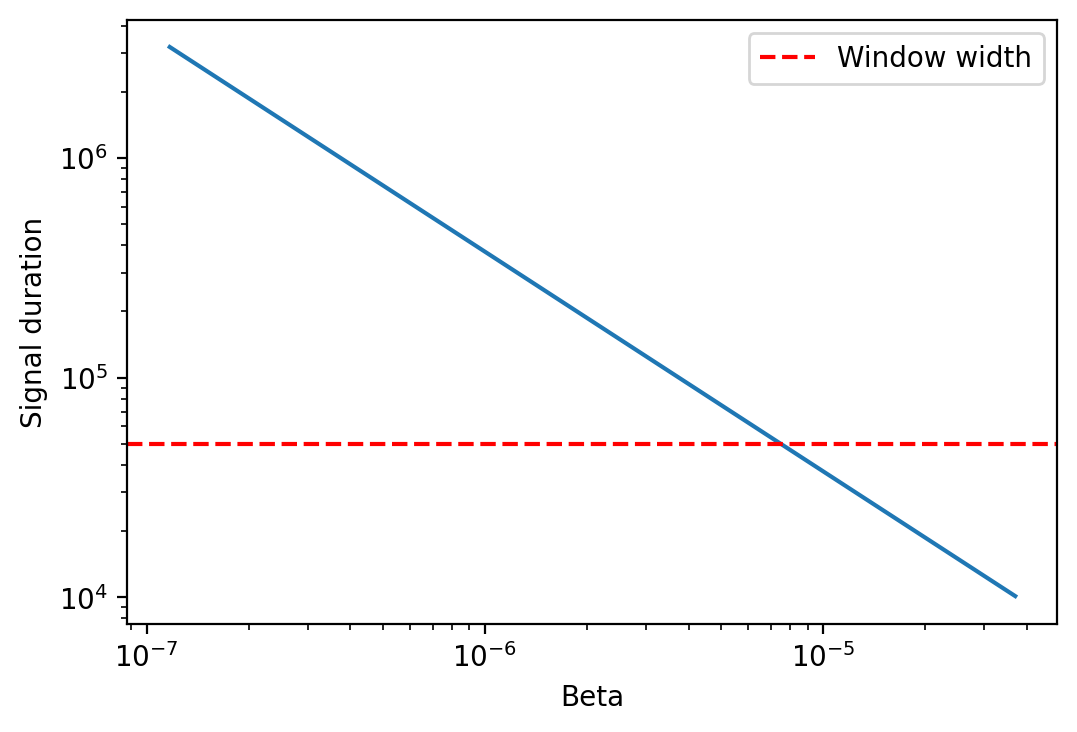

In [87]:
pl.loglog(beta_space, t_max_calc(f0, beta_space, 200))
pl.axhline(obs_duration, c='r', ls='--', label='Window width')
# pl.axvline(beta_space[8], c='r', ls='--')
pl.xlabel("Beta")
pl.ylabel(r'Signal duration')
pl.legend()

In [53]:
cross_idx = np.argmin(abs(t_max_calc(f0, beta_space, 200)-obs_duration))
np.log10(mass_space[cross_idx])

-1.4137931034482758